In [15]:
import pandas as pd 
import matplotlib.pyplot as plt 
df = pd.read_csv('Job Posts.csv')
df.head()


,Unnamed: 0,Job_Title,Job_Description,Job_Link
0,0,"Data Scientist (NiFi, DHF)",EducationBachelor's DegreeSkillsSQLTime Manage...,https://www.simplyhired.com/job/Tq4KqCrotc06Fp...
1,1,Data Scientist - Defense & Intelligence,EducationBachelor's DegreeSkillsNoSQLSQL401(k)...,https://www.simplyhired.com/job/OF7HNEC0sGEgBA...
2,2,Fall 2019/Winter 2020 Applied Science Machine ...,EducationDoctoral DegreeMaster's DegreeSkillsN...,https://www.simplyhired.com/job/WaFb8rbhCLxehi...
3,3,Applied Scientist Fall/Winter 2019 Internship ...,EducationDoctoral DegreeMaster's DegreeSkillsN...,https://www.simplyhired.com/job/BL2wIHWVfwAAgw...
4,4,"Data Scientist/Engineer (HDF, NiFi)",EducationBachelor's DegreeMaster's DegreeDocto...,https://www.simplyhired.com/job/1H_ga33Kqka5Ot...


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9067 entries, 0 to 9066
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Unnamed: 0       9067 non-null   int64
 1   Job_Title        9067 non-null   str  
 2   Job_Description  9067 non-null   str  
 3   Job_Link         9067 non-null   str  
dtypes: int64(1), str(3)
memory usage: 283.5 KB


In [17]:
df.isnull().sum()

Unnamed: 0         0
Job_Title          0
Job_Description    0
Job_Link           0
dtype: int64

In [18]:
df.describe()


,Unnamed: 0
count,9067.000000
mean,4533.000000
std,2617.561779
min,0.000000
25%,2266.500000
50%,4533.000000
75%,6799.500000
max,9066.000000


In [19]:
df.columns

Index(['Unnamed: 0', 'Job_Title', 'Job_Description', 'Job_Link'], dtype='str')

In [20]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,Job_Title,Job_Description,Job_Link
0,"Data Scientist (NiFi, DHF)",EducationBachelor's DegreeSkillsSQLTime Manage...,https://www.simplyhired.com/job/Tq4KqCrotc06Fp...
1,Data Scientist - Defense & Intelligence,EducationBachelor's DegreeSkillsNoSQLSQL401(k)...,https://www.simplyhired.com/job/OF7HNEC0sGEgBA...
2,Fall 2019/Winter 2020 Applied Science Machine ...,EducationDoctoral DegreeMaster's DegreeSkillsN...,https://www.simplyhired.com/job/WaFb8rbhCLxehi...
3,Applied Scientist Fall/Winter 2019 Internship ...,EducationDoctoral DegreeMaster's DegreeSkillsN...,https://www.simplyhired.com/job/BL2wIHWVfwAAgw...
4,"Data Scientist/Engineer (HDF, NiFi)",EducationBachelor's DegreeMaster's DegreeDocto...,https://www.simplyhired.com/job/1H_ga33Kqka5Ot...


In [21]:
python_count = df['Job_Description'].str.contains('Python', case=False).sum()
python_percentage = (python_count / len(df)) * 100
print(f'Total Jobs demanding Python: {python_count}')
print(f'Percentage of Jobs demanding Python: {python_percentage:.2f}%')

Total Jobs demanding Python: 3548
Percentage of Jobs demanding Python: 39.13%


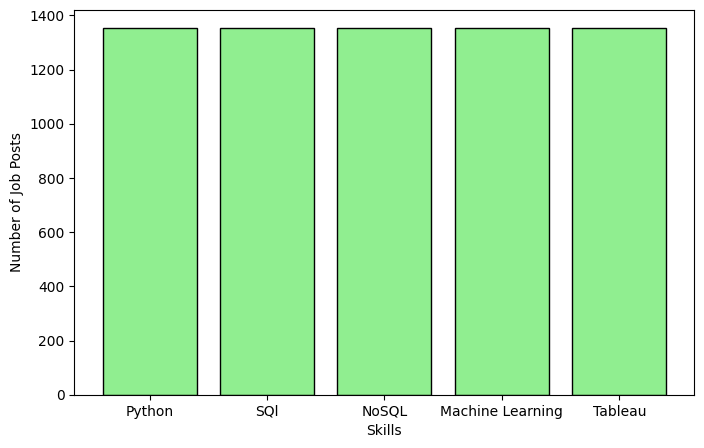

In [22]:
skills = ['Python', 'SQl', 'NoSQL', 'Machine Learning', 'Tableau', ]
counts = []
for skill in skills:
 count = df['Job_Description'].str.contains(skill, case=False).sum()
counts = counts + [count] 
plt.figure(figsize=(8, 5))
plt.bar(skills, counts, color='lightgreen', edgecolor='black')
plt.xlabel('Skills')
plt.ylabel('Number of Job Posts')
plt.show()


In [23]:
internships = df['Job_Title'].str.contains('Intern', case=False).sum()
senior_roles = df['Job_Title'].str.contains('Senior|Sr', case=False).sum()
print(f'Total Internship Posts: {internships}')
print(f'Total Senior Roles: {senior_roles}')

Total Internship Posts: 162
Total Senior Roles: 1290


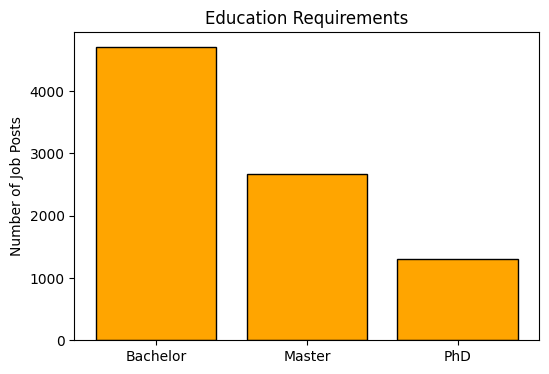

In [24]:
bachelor_count = df['Job_Description'].str.contains('Bachelor', case=False).sum()
master_count = df['Job_Description'].str.contains('Master', case=False).sum()
phd_count = df['Job_Description'].str.contains('Doctoral|PhD', case=False).sum()
edu_degrees = ['Bachelor', 'Master' , 'PhD']
edu_counts = [bachelor_count, master_count, phd_count]
plt.figure(figsize=(6, 4))
plt.bar(edu_degrees, edu_counts, color='orange', edgecolor='black')
plt.title('Education Requirements')
plt.ylabel('Number of Job Posts')
plt.show()

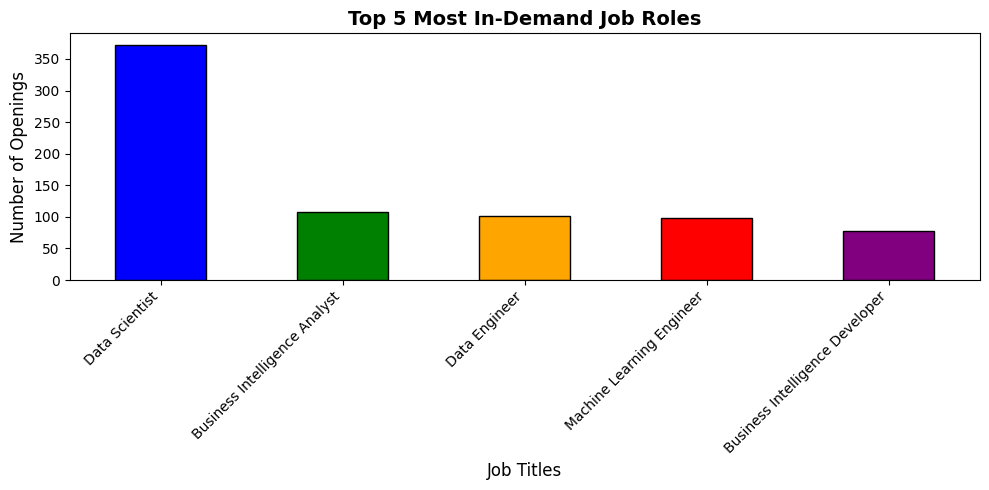

In [25]:
top_roles = df['Job_Title'].value_counts().head(5)
plt.figure(figsize=(10, 5))
top_roles.plot(kind='bar', color=['blue', 'green', 'orange', 'red', 'purple'], edgecolor='black')
plt.title('Top 5 Most In-Demand Job Roles', fontsize=14, fontweight='bold')
plt.xlabel('Job Titles', fontsize=12)
plt.ylabel('Number of Openings', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

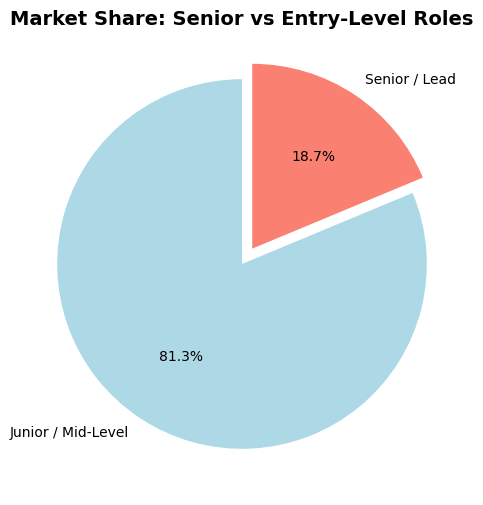

In [26]:
df['Is_Senior'] = df['Job_Title'].str.contains('Senior|Sr|LEAD|Principal', case=False)
role_type = df['Is_Senior'].value_counts()
plt.figure(figsize=(6, 6))
role_type.plot(kind='pie', labels=['Junior / Mid-Level', 'Senior / Lead'], autopct='%1.1f%%', colors=['lightblue', 'salmon'], startangle=90, explode=[0, 0.1])
plt.title('Market Share: Senior vs Entry-Level Roles', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.show()

In [27]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
data_scientist_jobs= df[df['Job_Title'].str.contains('Data Scientist', case=False, na=False)]
result_table = data_scientist_jobs[['Job_Title', 'Job_Link']].head(10)
print(result_table)

                                           Job_Title  \
0                         Data Scientist (NiFi, DHF)   
1            Data Scientist - Defense & Intelligence   
4                Data Scientist/Engineer (HDF, NiFi)   
6                                     Data Scientist   
9                     Data Scientist - Nashville, TN   
12    Data Scientist - AI/ML - Media & Entertainment   
13               Data Scientist - Spatial Statistics   
15                                    Data Scientist   
16                    Data Scientist - Nashville, TN   
22  DATA SCIENTIST (GIS AND GEOSPATIAL DATA SCIENCE)   

                                             Job_Link  
0   https://www.simplyhired.com/job/Tq4KqCrotc06Fp...  
1   https://www.simplyhired.com/job/OF7HNEC0sGEgBA...  
4   https://www.simplyhired.com/job/1H_ga33Kqka5Ot...  
6   https://www.simplyhired.com/job/DmtMp2rfvO2am6...  
9   https://www.simplyhired.com/job/FyvddizkFlJLSH...  
12  https://www.simplyhired.com/job/3f6TyQwhNaj

In [29]:
df.to_csv('Final_Cleaned_Job_Posts.csv', index=False)
print('Mubaarak ho! Cleaned data saved to "Final_Cleaned_Job_Posts.csv"')

Mubaarak ho! Cleaned data saved to "Final_Cleaned_Job_Posts.csv"
